# CreditMetrics Demo
This notebook demonstrates how to use the project after refactoring. The implementation lives in `src/`; this notebook simply orchestrates the workflow.

In [1]:
from src.config import (
    bond_names,
    CONFIDENCE_LEVELS,
    NUM_SCENARIOS,
    cholesky_matrix,
    rating_thresholds,
    alpha,
    beta_param,
    forward_values,
    exposures,
    initial_portfolio_value
)

from src.simulation import (
    generate_correlated_returns,
    map_returns_to_ratings,
    generate_recovery_rates,
)

from src.portfolio import (
    calculate_loan_forward_values,
    calculate_portfolio_values,
)

from src.risk_metrics import (
    calculate_losses,
    calculate_var_and_es
)

from src.visualisation import plot_loss_distribution

from tests.test_creditmetrics import (
    stability_analysis,
    convergence_plot_var,
    convergence_plot_es
)

from tests.test_transition import (
    row_count,
    transition_heatmap
)

## 1. Define model parameters

In [2]:
print(f"\nPortfolio Configuration:")
print(f"  Bonds: {', '.join(bond_names)}")
print(f"  Initial Portfolio Value: ${initial_portfolio_value:,.2f}")
print(f"  Number of Scenarios: {NUM_SCENARIOS:,}")
print(f"  Recovery Distribution: Beta(α={alpha}, β={beta_param})")
print(f"  Correlation Structure: Cholesky-induced")


Portfolio Configuration:
  Bonds: Boyd Gaming Corp, Brinker International Inc, American Airlines Group Inc
  Initial Portfolio Value: $15,222,963.00
  Number of Scenarios: 50,000
  Recovery Distribution: Beta(α=8.3653, β=13.7068)
  Correlation Structure: Cholesky-induced


## 2. Generate simulated scenarios

In [3]:
import numpy as np

In [4]:
print(f"Generating {NUM_SCENARIOS:,} correlated asset return scenarios...")
correlated_returns, uncorrelated_returns = generate_correlated_returns(
    NUM_SCENARIOS, cholesky_matrix, num_bonds=3
)

print(f"\nMapping returns to rating scenarios using thresholds...")
rating_scenarios = map_returns_to_ratings(
    correlated_returns, rating_thresholds
)

print(f"  Uncorrelated returns shape: {uncorrelated_returns.shape}")
print(f"  Correlated returns shape: {correlated_returns.shape}")
print(f"  Correlation matrix (from data):\n{np.corrcoef(correlated_returns.T)}")

# Summary of rating distributions
for bond_name in bond_names:
    ratings = rating_scenarios[bond_name]
    unique, counts = np.unique(ratings, return_counts=True)
    print(f"\n  {bond_name}:")
    for rating_label, count in zip(unique, counts):
        pct = (count / NUM_SCENARIOS) * 100
        print(f"    {rating_label:8s}: {count:>6,} scenarios ({pct:>5.2f}%)")

print(f"\nGenerating uncorrelated recovery rates using Beta distribution...")
recovery_rates, uniform_random = generate_recovery_rates(
    NUM_SCENARIOS, alpha, beta_param, num_bonds=3
)

print(f"  Uniform random values shape: {uniform_random.shape}")
print(f"  Recovery rates shape: {recovery_rates.shape}")
print(f"  Recovery statistics:")
print(f"  Mean recovery: {np.mean(recovery_rates):.4f}")
print(f"  Std recovery:  {np.std(recovery_rates):.4f}")
print(f"  Min recovery:  {np.min(recovery_rates):.4f}")
print(f"  Max recovery:  {np.max(recovery_rates):.4f}")

Generating 50,000 correlated asset return scenarios...

Mapping returns to rating scenarios using thresholds...
  Uncorrelated returns shape: (50000, 3)
  Correlated returns shape: (50000, 3)
  Correlation matrix (from data):
[[1.         0.525958   0.46465949]
 [0.525958   1.         0.4288979 ]
 [0.46465949 0.4288979  1.        ]]

  Boyd Gaming Corp:
    B       :  2,372 scenarios ( 4.74%)
    Ba      : 46,780 scenarios (93.56%)
    Baa     :    212 scenarios ( 0.42%)
    Caa-C   :    431 scenarios ( 0.86%)
    Default :    205 scenarios ( 0.41%)

  Brinker International Inc:
    B       :  2,325 scenarios ( 4.65%)
    Ba      : 46,771 scenarios (93.54%)
    Baa     :    241 scenarios ( 0.48%)
    Caa-C   :    441 scenarios ( 0.88%)
    Default :    222 scenarios ( 0.44%)

  American Airlines Group Inc:
    B       : 39,210 scenarios (78.42%)
    Ba      :  9,478 scenarios (18.96%)
    Baa     :    443 scenarios ( 0.89%)
    Caa-C   :    869 scenarios ( 1.74%)

Generating uncorrelat

## 3. Value the portfolio

In [5]:
print(f"\nCalculating implied forward loan values...")
loan_forward_values = calculate_loan_forward_values(
    rating_scenarios, recovery_rates, forward_values, exposures
)

for bond_name in bond_names:
    values = loan_forward_values[bond_name]
    print(f"\n  {bond_name}:")
    print(f"    Mean forward value: ${np.mean(values):>15,.2f}")
    print(f"    Std forward value:  ${np.std(values):>15,.2f}")
    print(f"    Min forward value:  ${np.min(values):>15,.2f}")
    print(f"    Max forward value:  ${np.max(values):>15,.2f}")

print(f"\nAggregating to portfolio values...")
portfolio_values = calculate_portfolio_values(loan_forward_values)
    
print(f"  Portfolio values shape: {portfolio_values.shape}")
print(f"  Portfolio value statistics:")
print(f"  Mean portfolio value: ${np.mean(portfolio_values):>15,.2f}")
print(f"  Std portfolio value:  ${np.std(portfolio_values):>15,.2f}")
print(f"  Min portfolio value:  ${np.min(portfolio_values):>15,.2f}")
print(f"  Max portfolio value:  ${np.max(portfolio_values):>15,.2f}")



Calculating implied forward loan values...

  Boyd Gaming Corp:
    Mean forward value: $   3,961,476.71
    Std forward value:  $     164,768.64
    Min forward value:  $     417,107.08
    Max forward value:  $   4,042,173.00

  Brinker International Inc:
    Mean forward value: $   5,055,906.61
    Std forward value:  $     217,901.03
    Min forward value:  $     848,704.24
    Max forward value:  $   5,201,549.00

  American Airlines Group Inc:
    Mean forward value: $   6,132,878.06
    Std forward value:  $     120,924.06
    Min forward value:  $   5,534,339.00
    Max forward value:  $   6,509,991.00

Aggregating to portfolio values...
  Portfolio values shape: (50000,)
  Portfolio value statistics:
  Mean portfolio value: $  15,150,261.39
  Std portfolio value:  $     327,113.08
  Min portfolio value:  $   8,437,829.07
  Max portfolio value:  $  15,753,713.00


## 4. Calculate portfolio risk

In [6]:
print(f"\nCalculating portfolio losses...")
losses = calculate_losses(portfolio_values, initial_portfolio_value)
    
print(f"  Loss statistics:")
print(f"    Mean loss:    ${np.mean(losses):>15,.2f}")
print(f"    Median loss:  ${np.median(losses):>15,.2f}")
print(f"    Std loss:     ${np.std(losses):>15,.2f}")
print(f"    Min loss:     ${np.min(losses):>15,.2f}")
print(f"    Max loss:     ${np.max(losses):>15,.2f}")

print(f"\nCalculating Absolute VaR and Expected Shortfall...")
results = calculate_var_and_es(losses, CONFIDENCE_LEVELS)

for conf in sorted(CONFIDENCE_LEVELS):
    conf_pct = int(conf * 100)
    var = results[conf]['VaR']
    es = results[conf]['ES']
        
    print(f"\nConfidence Level: {conf_pct}%")
    print(f"  Absolute VaR:              ${var:>15,.2f}")
    print(f"  Absolute Expected Shortfall: ${es:>15,.2f}")
    print(f"  Tail Observations:         {results[conf]['num_tail']:>15,} ({results[conf]['pct_tail']:.2f}%)")



Calculating portfolio losses...
  Loss statistics:
    Mean loss:    $      72,701.61
    Median loss:  $      66,044.00
    Std loss:     $     327,113.08
    Min loss:     $    -530,750.00
    Max loss:     $   6,785,133.93

Calculating Absolute VaR and Expected Shortfall...

Confidence Level: 95%
  Absolute VaR:              $     213,836.00
  Absolute Expected Shortfall: $     694,018.19
  Tail Observations:                   3,879 (7.76%)

Confidence Level: 99%
  Absolute VaR:              $     866,860.00
  Absolute Expected Shortfall: $   2,755,088.59
  Tail Observations:                     513 (1.03%)


## 5. Visualise results

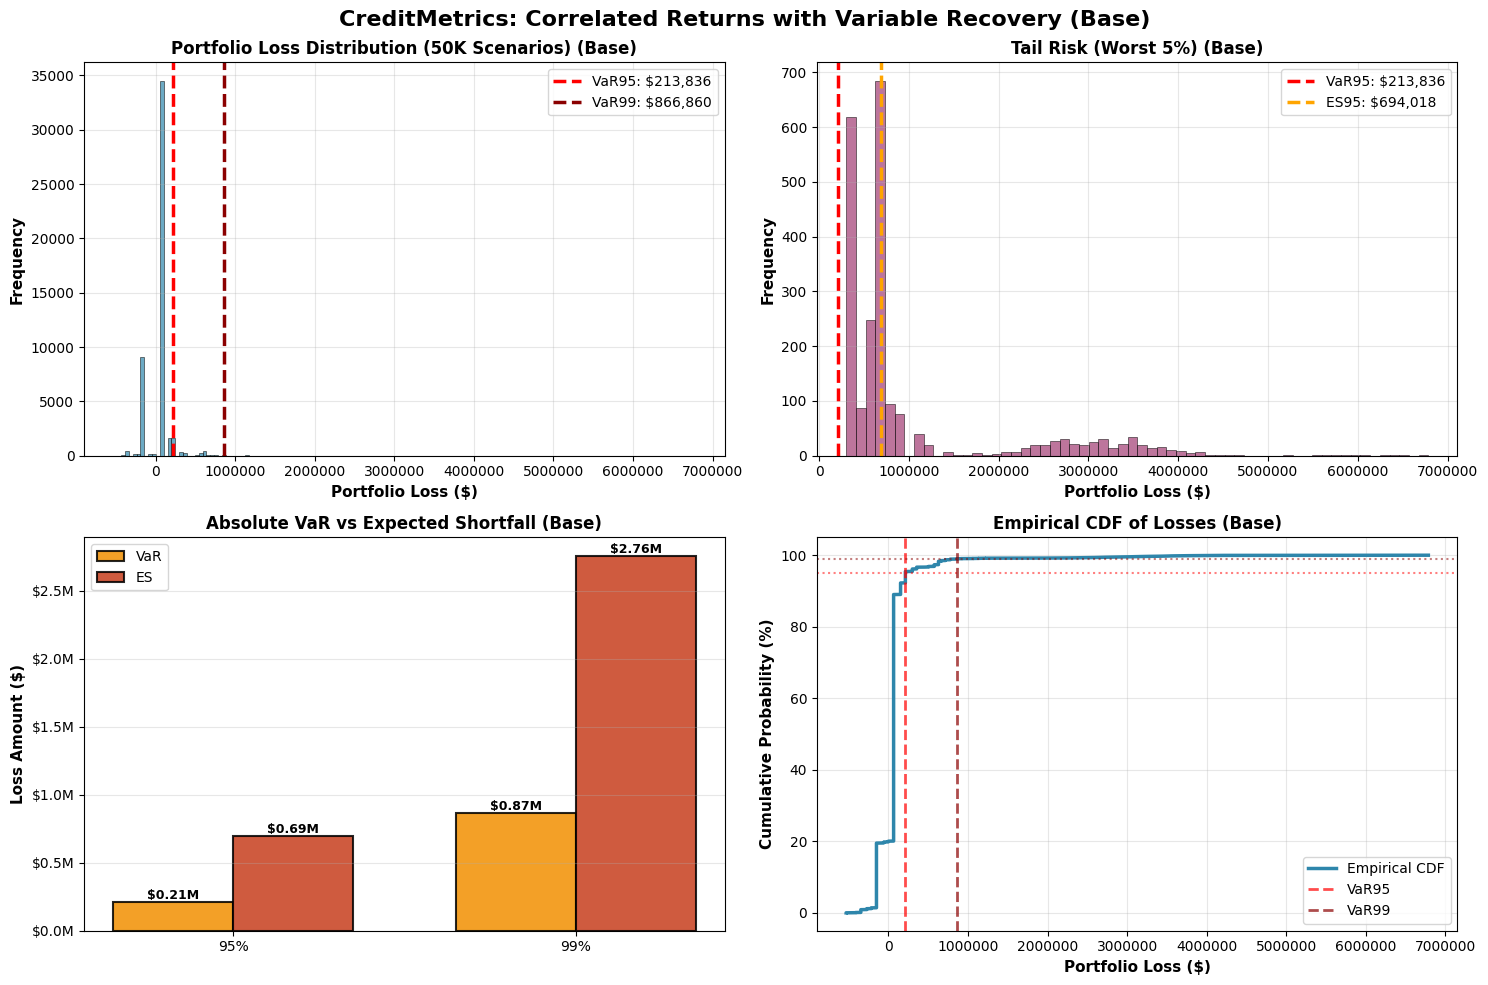

In [7]:
plot_loss_distribution(losses, results)

## 6. Testing

In [16]:
var_results, es_results = stability_analysis(num_replications = 100)


STABILITY ANALYSIS
Number of replications: 100
Scenarios per replication: 50,000

99% VaR
Mean: 876,893.78
Std Dev: 29,934.99
CV: 3.414%

99% Expected Shortfall
Mean: 2,708,658.16
Std Dev: 120,618.67
CV: 4.453%

99% Confidence Interval
VaR: [864,248.66, 922,662.06]
ES : [2,483,855.99, 2,953,313.72]


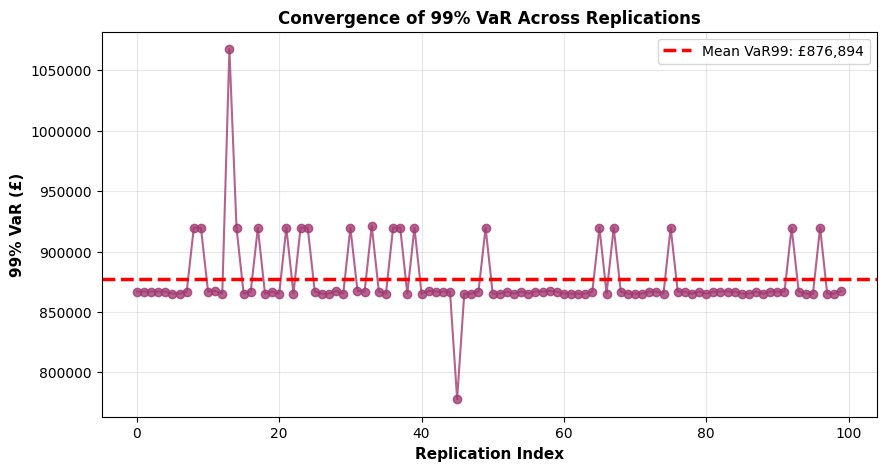

In [17]:
convergence_plot_var(var_results)

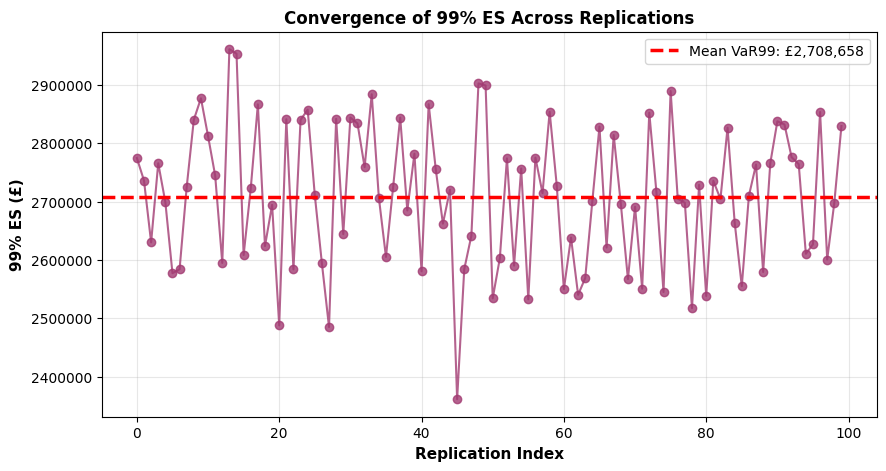

In [18]:
convergence_plot_es(es_results)

In [9]:
transition_df = row_count('transition_matrix.csv')

Aaa     1.0000
Aa1     1.0000
Aa2     1.0000
Aa3     1.0000
A1      1.0001
A2      1.0000
A3      1.0000
Baa1    0.9999
Baa2    1.0000
Baa3    0.9999
Ba1     1.0001
Ba2     0.9999
Ba3     0.9998
B1      1.0002
B2      1.0000
B3      0.9999
Caa1    1.0000
Caa2    0.9999
Caa3    1.0000
Ca-C    1.0000
D       1.0000
dtype: float64


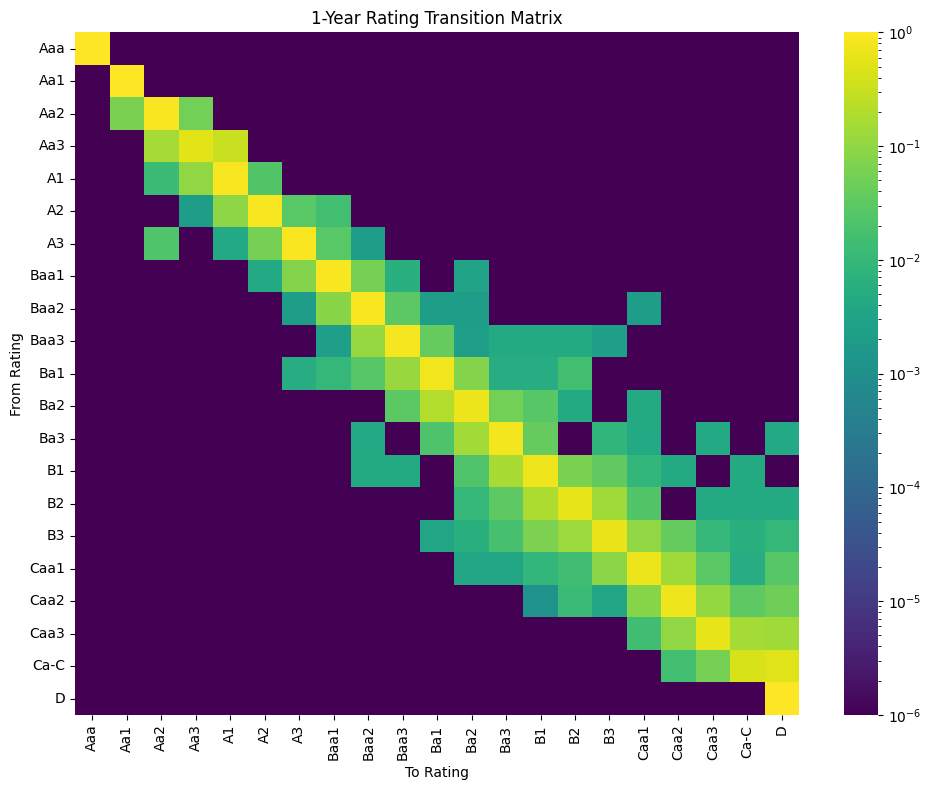

In [10]:
transition_heatmap(transition_df)